In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#TODO: SACAR LOS VALORES DE DIFERENTE TASA DE CRECIMIENTO

In [25]:
excel = pd.ExcelFile('Data/data_important.xlsx')
excel.sheet_names

['Proteins',
 'ProteinRead',
 'Metabolites',
 'MetaboliteRead',
 'Fluxes',
 'FluxesRead',
 'Extracelular',
 'ExtracelularRead']

In [26]:
proteins = excel.parse('ProteinRead', index_col=0)
metabolites = excel.parse('MetaboliteRead', index_col=0)
fluxes = excel.parse('FluxesRead', index_col=0)
external_metabolites = excel.parse('ExtracelularRead', index_col=0)

In [27]:
# important enzymes
important_enzymes = [
    'pgi',
    'pfkB',
    'fbaA',
    'tpiA',
    'gapA',
    'pgk',
    'gpmA',
    'eno',
]

prot_filter = proteins.index.isin(important_enzymes)
prot_fil = proteins[prot_filter]

balanced_metabolites = [
    'Glucose 6-phosphate', # si g6p
    'Fructose 6-phosphate', # si f6p
    'Fructose 1,6-diphosphate', # si fbp
    'Dihydroxyacetone phosphate', # si dhap
    'Glyceraldehyde 3-phosphate', # no g3p
    '1,3-Bisphosphoglycerate', # no pgp
    '3-Phosphoglycerate', # si 3pg
    '2-Phosphoglycerate', # no 2pg
    'Phosphoenolpyruvate', # si pep
]

imbalanced_metabolites = [
    'ATP',
    'ADP',
    'AMP',
    'GDP',
    'GLC', #<- extracelular glucose,
    'GTP',
    'NAD', 
    'NADH',
    'Inorganic phosphate',
    'Pyruvate',
]

balanced_metabolites_filter = metabolites.index.isin(balanced_metabolites)
imbalanced_metabolites_filter = metabolites.index.isin(imbalanced_metabolites)

balanced_mets_df = metabolites[balanced_metabolites_filter]
imbalanced_mets_df = metabolites[imbalanced_metabolites_filter]


external_glucose = external_metabolites.index.isin(['Glucose'])
external_glucose_df = external_metabolites[external_glucose]
imbalanced_mets_df = pd.concat([imbalanced_mets_df, external_glucose_df])

important_fluxes = [
    'Glucose + PEP -> G6P + PYR', # pts
    'G6P <-> F6P', # pgi
    'F6P -> F1,6P', # pfkA
    'F1,6P -> DHAP + G3P', # fbaA
    'DHAP -> G3P', # tpiA
    'G3P -> PGP', # gapA
    'PGP -> 3PG', # pgk
    '3PG <-> 2PG', # gpmA
    '2PG <-> PEP', # eno
    
]
flux_filter = fluxes.index.isin(important_fluxes)

def batch_replace(x):
    if type(x) == str:
        return x.replace(' ', '')

    return x

flux_fil = fluxes[flux_filter].apply(lambda x: x.fillna(0))
flux_fil = flux_fil.apply(lambda x: x.replace('-', 0))

# important external metabolite 
important_external_met= [
    'Glucose',
]
external_met_filter = external_metabolites.index.isin(important_external_met)
external_met_fil = external_metabolites[external_met_filter]
###

columns_consensus = balanced_mets_df.columns.intersection(imbalanced_mets_df.columns).intersection(flux_fil.columns).intersection(prot_fil.columns)
balanced_mets_df = balanced_mets_df[columns_consensus]
imbalanced_mets_df = imbalanced_mets_df[columns_consensus]
flux_fil = flux_fil[columns_consensus]
prot_fil = prot_fil[columns_consensus]

/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_22754/2275593141.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flux_fil = fluxes[flux_filter].apply(lambda x: x.fillna(0))
/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_22754/2275593141.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flux_fil = flux_fil.apply(lambda x: x.replace('-', 0))


In [28]:
balanced_mets_df
dict_balanced = {
    'Phosphoenolpyruvate': 'C_pep',
    'Dihydroxyacetone phosphate': 'C_dhap',
    '3-Phosphoglycerate': 'C_3pg',
    'Fructose 6-phosphate': 'C_f6p',
    'Fructose 1,6-diphosphate': 'C_fbp',
    'Glucose 6-phosphate': 'C_g6p',
}
balanced_mets_df['VarNames'] = balanced_mets_df.index.map(dict_balanced)
balanced_mets_df.index = balanced_mets_df['VarNames']
dict_imbalanced = {
    'ATP': 'C_atp',
    'ADP': 'C_adp',
    'AMP': 'C_amp',
    'GDP': 'C_gdp',
    'Glucose': 'C_glc',
    'GTP': 'C_gtp',
    'NAD': 'C_nad',
    'NADH': 'C_nadh',
    'Inorganic phosphate': 'C_pi',
    'Pyruvate': 'C_pyr',
}
imbalanced_mets_df['VarNames'] = imbalanced_mets_df.index.map(dict_imbalanced)
imbalanced_mets_df.index = imbalanced_mets_df['VarNames']

In [29]:
dict_proteins = {
    'pgi': 'Pgi',
    'pfkB': 'PfkB',
    'fbaA': 'FbaA',
    'tpiA': 'TpiA',
    'gapA': 'GapA',
    'pgk': 'Pgk',
    'gpmA': 'GpmA',
    'eno': 'Eno',
}
prot_fil['VarNames'] = prot_fil.index.map(dict_proteins)
prot_fil
prot_fil.index = prot_fil['VarNames']

In [30]:
dict_flux_name = {
    'Glucose + PEP -> G6P + PYR': 'v_pts',
    'G6P <-> F6P': 'v_pgi',
    'F6P -> F1,6P': 'v_pfkB',
    'F1,6P -> DHAP + G3P': 'v_fbaA',
    'DHAP -> G3P': 'v_tpiA',
    'G3P -> PGP': 'v_gapA',
    'PGP -> 3PG': 'v_pgk',
    '3PG <-> 2PG': 'v_gpmA',
    '2PG <-> PEP': 'v_eno',
}
flux_fil['VarNames'] = flux_fil.index.map(dict_flux_name)
flux_fil
flux_fil.index = flux_fil['VarNames']

In [31]:
flux_fil.index

Index(['v_pts', 'v_pgi', 'v_pfkB', 'v_fbaA', 'v_tpiA', 'v_gapA', 'v_pgk',
       'v_gpmA', 'v_eno'],
      dtype='object', name='VarNames')

In [32]:
# to csv
balanced_mets_df.drop(columns=['VarNames'], inplace=True)
imbalanced_mets_df.drop(columns=['VarNames'], inplace=True)
prot_fil.drop(columns=['VarNames'], inplace=True)
flux_fil.drop(columns=['VarNames'], inplace=True)
balanced_mets_df.to_csv('Data/balanced_metabolites.csv')
imbalanced_mets_df.to_csv('Data/imbalanced_metabolites.csv')
prot_fil.to_csv('Data/important_proteins.csv')
flux_fil.to_csv('Data/important_fluxes.csv')

In [33]:
N = np.array(
        [
            # pts  pgi  pfk  fba  tpi  gap  pgk  gpm  eno
            [0 , 0 , 0 , 0 , 0 , 0 , 0 , 1 , -1],  # 2pg
            [0 , 0 , 0 , 0 , 0 , 0 , 1 , -1, 0 ],  # 3pg
            [0 , 0 , 0 , 1 , -1, 0 , 0 , 0 , 0 ],  # dhap
            [0 , 1 , -1, 0 , 0 , 0 , 0 , 0 , 0 ],  # f6p
            [0 , 0 , 1 , -1, 0 , 0 , 0 , 0 , 0 ],  # fbp
            [0 , 0 , 0 , 1 , 1 , -1, 0 , 0 , 0 ],  # g3p
            [1 , -1, 0 , 0 , 0 , 0 , 0 , 0 , 0 ],  # g6p
            [-1, 0 , 0 , 0 , 0 , 0 , 0 , 0 , 1 ],  # pep
            [0 , 0 , 0 , 0 , 0 , 1 , -1, 0 , 0 ],  # pgp
        ]
    )

metabolites = ["2pg", "3pg", "dhap", "f6p", "fbp", "g3p", "g6p", "pep", "pgp"]
reactions = ["pts", "pgi", "pfk", "fba", "tpi", "gap", "pgk", "gpm", "eno"]

S = pd.DataFrame(N, index=metabolites, columns=reactions)

In [34]:
df_cellular_needs = {}
for conditions in flux_fil.columns:
    flux = flux_fil[conditions].values
    needs = S @ flux
    df_cellular_needs[conditions] = needs
df_cellular_needs = pd.DataFrame(df_cellular_needs, index=metabolites)
df_cellular_needs.index = df_cellular_needs.index.map({
    '2pg': 'C_2pg',
    '3pg': 'C_3pg',
    'dhap': 'C_dhap',
    'f6p': 'C_f6p',
    'fbp': 'C_fbp',
    'g3p': 'C_g3p',
    'g6p': 'C_g6p',
    'pep': 'C_pep',
    'pgp': 'C_pgp',
})
df_cellular_needs.to_csv('Data/cellular_needs.csv')



In [39]:
df_cellular_needs

,KO02,KO03,KO04,KO05,KO06,KO07,KO08,KO10,KO11,KO12,...,KO19,KO20,KO21,KO22,KO23,KO24,GR01,GR02,GR03,GR04
C_2pg,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
C_3pg,0.3140,0.2754,0.3003,0.2992,0.2840,0.297,0.2760,0.297,0.2997,0.2820,...,0.2862,0.2905,0.3143,0.2970,0.308,0.2940,0.1340,0.6060,0.7293,1.0672
C_dhap,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
C_f6p,-0.0628,-0.2448,-0.9282,-0.0816,-0.7100,-0.054,-0.2760,-0.081,-0.0666,-0.2820,...,-0.0636,-1.1620,-0.0449,-0.0594,-0.056,-0.0588,-0.2412,-0.8080,-0.2652,-3.2016
C_fbp,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
C_g3p,0.0314,-0.0306,-1.4196,0.0272,-0.2556,0.027,-0.0828,0.000,0.0666,-0.0564,...,-0.6042,-0.4565,-0.5837,0.0297,0.000,0.0294,-0.0938,-0.3535,0.0663,-1.3340
C_g6p,0.4082,0.6732,2.7300,0.4352,1.3632,0.405,0.7452,0.459,0.3996,0.7332,...,1.0494,2.0335,0.9878,0.4158,0.420,0.4116,0.5092,1.8685,1.1271,5.8696
C_pep,2.1038,1.9584,0.2457,1.6864,1.5052,1.674,1.6284,1.647,2.2977,1.6920,...,1.5264,2.5730,2.8736,1.9305,1.764,1.9110,0.7638,2.6765,4.1106,8.2708
C_pgp,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000


In [36]:
flux_fil

,KO02,KO03,KO04,KO05,KO06,KO07,KO08,KO10,KO11,KO12,...,KO19,KO20,KO21,KO22,KO23,KO24,GR01,GR02,GR03,GR04
VarNames,,,,,,,,,,,,,,,,,,,,,
v_pts,3.1400,3.0600,2.7300,2.7200,2.8400,2.700,2.7600,2.700,3.3300,2.8200,...,3.1800,4.1500,4.4900,2.9700,2.800,2.9400,1.3400,5.0500,6.6300,13.3400
v_pgi,2.7318,2.3868,0.0000,2.2848,1.4768,2.295,2.0148,2.241,2.9304,2.0868,...,2.1306,2.1165,3.5022,2.5542,2.380,2.5284,0.8308,3.1815,5.5029,7.4704
v_pfkB,2.7946,2.6316,0.9282,2.3664,2.1868,2.349,2.2908,2.322,2.9970,2.3688,...,2.1942,3.2785,3.5471,2.6136,2.436,2.5872,1.0720,3.9895,5.7681,10.6720
v_fbaA,2.7946,2.6316,0.9282,2.3664,2.1868,2.349,2.2908,2.322,2.9970,2.3688,...,2.1942,3.2785,3.5471,2.6136,2.436,2.5872,1.0720,3.9895,5.7681,10.6720
v_tpiA,2.7946,2.6316,0.9282,2.3664,2.1868,2.349,2.2908,2.322,2.9970,2.3688,...,2.1942,3.2785,3.5471,2.6136,2.436,2.5872,1.0720,3.9895,5.7681,10.6720
v_gapA,5.5578,5.2938,3.2760,4.7056,4.6292,4.671,4.6644,4.644,5.9274,4.7940,...,4.9926,7.0135,7.6779,5.1975,4.872,5.1450,2.2378,8.3325,11.4699,22.6780
v_pgk,5.5578,5.2938,3.2760,4.7056,4.6292,4.671,4.6644,4.644,5.9274,4.7940,...,4.9926,7.0135,7.6779,5.1975,4.872,5.1450,2.2378,8.3325,11.4699,22.6780
v_gpmA,5.2438,5.0184,2.9757,4.4064,4.3452,4.374,4.3884,4.347,5.6277,4.5120,...,4.7064,6.7230,7.3636,4.9005,4.564,4.8510,2.1038,7.7265,10.7406,21.6108
v_eno,5.2438,5.0184,2.9757,4.4064,4.3452,4.374,4.3884,4.347,5.6277,4.5120,...,4.7064,6.7230,7.3636,4.9005,4.564,4.8510,2.1038,7.7265,10.7406,21.6108


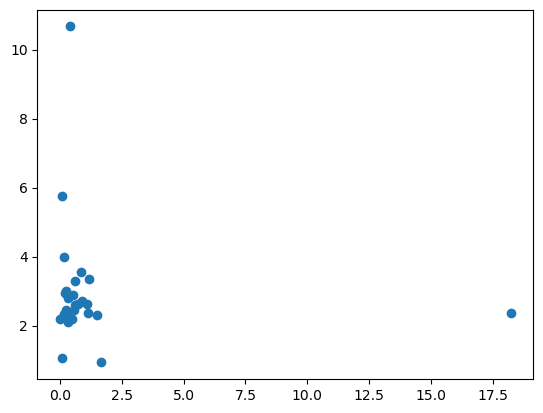

In [37]:
plt.scatter(
    prot_fil.iloc[1, :],
    flux_fil.iloc[2, :]
)


In [38]:
prot_fil.iloc[1, :]

KO02     0.310924
KO03     1.075630
KO04     1.672269
KO05    18.235294
KO06     0.000000
KO07     1.126050
KO08     1.495798
KO10     0.158824
KO11     0.243697
KO12     0.300000
KO13     0.331933
KO14     0.244538
KO15     0.215126
KO16     0.505042
KO17     0.890756
KO18     1.159664
KO19     0.481513
KO20     0.593277
KO21     0.848739
KO22     0.744538
KO23     0.581513
KO24     0.605042
GR01     0.069832
GR02     0.166387
GR03     0.079496
GR04     0.387395
Name: PfkB, dtype: float64